# **I. TÓM TẮT**

Nội dung của file này là tiến hành so sánh các mô hình học máy với nhau và chọn ra mô hình tốt nhất.

Các mô hình được so sánh:
- XGBoost Classifier
- Logistic Regression
- K-Nearest Neighbors
- Decision Tree Classifier
- Random Forest Classifier
- AdaBoost Classifier

***-> Mô hình có kết quả tốt nhất là XGBoost Classifier***

# **II. DỮ LIỆU**

### 1. Thêm dữ liệu

In [26]:
# Thêm dữ liệu
import gdown

file_id = '10XOY2JXYuRpoVTCZhO9nVouaueK-CjoB'
output_filename = 'data.csv'

gdown.download(id=file_id, output=output_filename, quiet=False)
print(f"File downloaded as {output_filename}")

Downloading...
From: https://drive.google.com/uc?id=10XOY2JXYuRpoVTCZhO9nVouaueK-CjoB
To: /content/data.csv
100%|██████████| 776k/776k [00:00<00:00, 113MB/s]

File downloaded as data.csv


In [27]:
import pandas as pd

df = pd.read_csv(output_filename)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1442 entries, 0 to 1441
Data columns (total 43 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   date                             1442 non-null   object 
 1   close                            1442 non-null   float64
 2   open                             1442 non-null   float64
 3   high                             1442 non-null   float64
 4   low                              1442 non-null   float64
 5   vol                              1442 non-null   float64
 6   zero_balance_addresses_all_time  1442 non-null   int64  
 7   unique_addresses_all_time        1442 non-null   int64  
 8   new_addresses                    1442 non-null   int64  
 9   active_addresses                 1442 non-null   int64  
 10  transaction_count                1442 non-null   int64  
 11  transaction_count_all_time       1442 non-null   int64  
 12  large_transaction_co

### 2. Chuẩn bị dữ liệu cho mô hình


In [28]:
# Chuẩn bị dữ liệu cho mô hình

df['date'] = pd.to_datetime(df['date'], errors='coerce')
df.dropna(subset=['date'], inplace=True)

df['target'] = (df['close'].diff() > 0).astype(int)
df['target'] = df['target'].fillna(0)

y = df['target']
X = df.drop(columns=['date', 'close', 'target', 'avg_sentiment_score'])

# Chronological split
split_index = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print("Data preparation for XGBClassifier (binary) complete.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Data preparation for XGBClassifier (binary) complete.
X_train shape: (1153, 40)
X_test shape: (289, 40)
y_train shape: (1153,)
y_test shape: (289,)


# **III. HUẤN LUYỆN MÔ HÌNH**

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
import xgboost as xgb

In [30]:
models = []

# Add the existing XGBoost Classifier
models.append(('XGBoost Classifier', xgb.XGBClassifier(random_state=42)))
# Initialize and add other classification models
models.append(('Logistic Regression', LogisticRegression(random_state=42, solver='liblinear')))
models.append(('K-Nearest Neighbors', KNeighborsClassifier(n_neighbors=5)))
models.append(('Decision Tree Classifier', DecisionTreeClassifier(random_state=42)))
models.append(('Random Forest Classifier', RandomForestClassifier(n_estimators=100, random_state=42)))
models.append(('AdaBoost Classifier', AdaBoostClassifier(n_estimators=100, random_state=42)))

print("Khởi tạo các mô hình sau để so sánh:")
for name, _ in models:
    print(f"- {name}")

Khởi tạo các mô hình sau để so sánh:
- XGBoost Classifier
- Logistic Regression
- K-Nearest Neighbors
- Decision Tree Classifier
- Random Forest Classifier
- AdaBoost Classifier


In [31]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc

results = []
confusion_matrices = {}
roc_plots_data = [] # List to store data for ROC plots

for name, model in models:
    print(f"\nHuấn luyện và đánh giá {name}...")

    # Huấn luyện mô hình
    model.fit(X_train, y_train)

    # Thực hiện dự đoán trên tập kiểm tra
    y_pred = model.predict(X_test)

    # Tính toán xác suất dự đoán cho đường cong ROC
    if hasattr(model, "predict_proba"):
        y_pred_proba = model.predict_proba(X_test)[:, 1]
    else:
        # Một số mô hình không có predict_proba, fallback sử dụng predict
        # Lưu ý: Việc này không lý tưởng cho ROC, nhưng cần thiết nếu không có predict_proba
        y_pred_proba = y_pred
        print(f"Cảnh báo: Mô hình {name} không có predict_proba. Đang sử dụng các lớp dự đoán cho ROC.")

    # Tính toán các chỉ số phân loại
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    # Lưu trữ kết quả
    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-score': f1
    })
    confusion_matrices[name] = cm

    # Lưu trữ dữ liệu cho đường cong ROC
    roc_plots_data.append({'Model': name, 'y_test': y_test, 'y_pred_proba': y_pred_proba})

    print(f"  - Độ chính xác (Accuracy): {accuracy:.4f}")
    print(f"  - Độ chính xác (Precision): {precision:.4f}")
    print(f"  - Độ thu hồi (Recall): {recall:.4f}")
    print(f"  - Điểm F1 (F1-score): {f1:.4f}")

print("\nHoàn thành huấn luyện và đánh giá mô hình.")


Huấn luyện và đánh giá XGBoost Classifier...
  - Độ chính xác (Accuracy): 0.8651
  - Độ chính xác (Precision): 0.8776
  - Độ thu hồi (Recall): 0.8600
  - Điểm F1 (F1-score): 0.8687

Huấn luyện và đánh giá Logistic Regression...
  - Độ chính xác (Accuracy): 0.5190
  - Độ chính xác (Precision): 0.5190
  - Độ thu hồi (Recall): 1.0000
  - Điểm F1 (F1-score): 0.6834

Huấn luyện và đánh giá K-Nearest Neighbors...
  - Độ chính xác (Accuracy): 0.4740
  - Độ chính xác (Precision): 0.4688
  - Độ thu hồi (Recall): 0.1000
  - Điểm F1 (F1-score): 0.1648

Huấn luyện và đánh giá Decision Tree Classifier...
  - Độ chính xác (Accuracy): 0.7266
  - Độ chính xác (Precision): 0.8447
  - Độ thu hồi (Recall): 0.5800
  - Điểm F1 (F1-score): 0.6877

Huấn luyện và đánh giá Random Forest Classifier...
  - Độ chính xác (Accuracy): 0.7889
  - Độ chính xác (Precision): 0.9159
  - Độ thu hồi (Recall): 0.6533
  - Điểm F1 (F1-score): 0.7626

Huấn luyện và đánh giá AdaBoost Classifier...
  - Độ chính xác (Accuracy): 

# **IV. KẾT QUẢ**

## 1. Các chỉ số

In [32]:
results_df = pd.DataFrame(results)
print("So sánh kết quả các mô hình:\n")
print(results_df)

So sánh kết quả các mô hình:

                      Model  Accuracy  Precision    Recall  F1-score
0        XGBoost Classifier  0.865052   0.877551  0.860000  0.868687
1       Logistic Regression  0.519031   0.519031  1.000000  0.683371
2       K-Nearest Neighbors  0.474048   0.468750  0.100000  0.164835
3  Decision Tree Classifier  0.726644   0.844660  0.580000  0.687747
4  Random Forest Classifier  0.788927   0.915888  0.653333  0.762646
5       AdaBoost Classifier  0.865052   0.853503  0.893333  0.872964


## 2. Ma trận nhầm lẫn

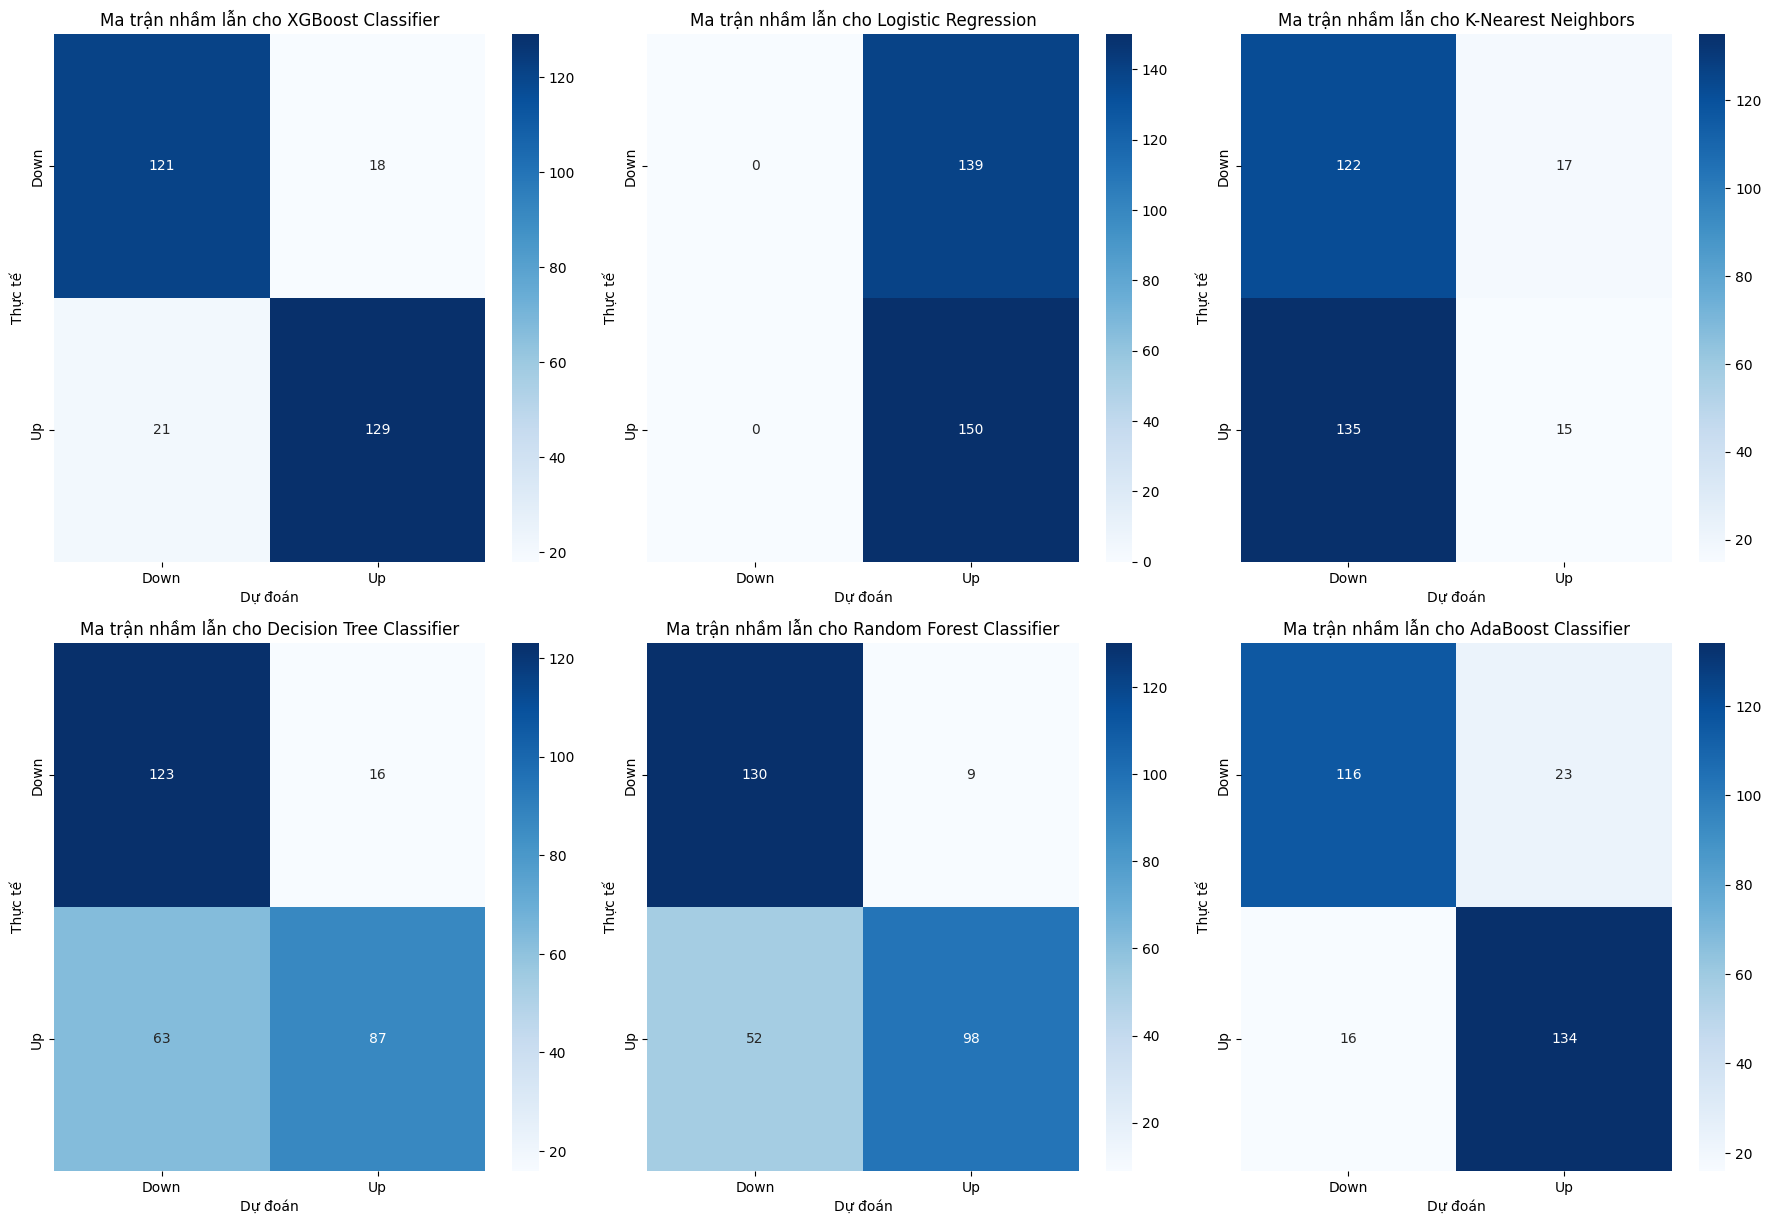

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting confusion matrices for all models
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 18))
axes = axes.flatten()

for i, (name, cm) in enumerate(confusion_matrices.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'], ax=axes[i])
    axes[i].set_title(f'Ma trận nhầm lẫn cho {name}')
    axes[i].set_xlabel('Dự đoán')
    axes[i].set_ylabel('Thực tế')

# Hide any unused subplots
for j in range(len(confusion_matrices), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 3. ROC Curve

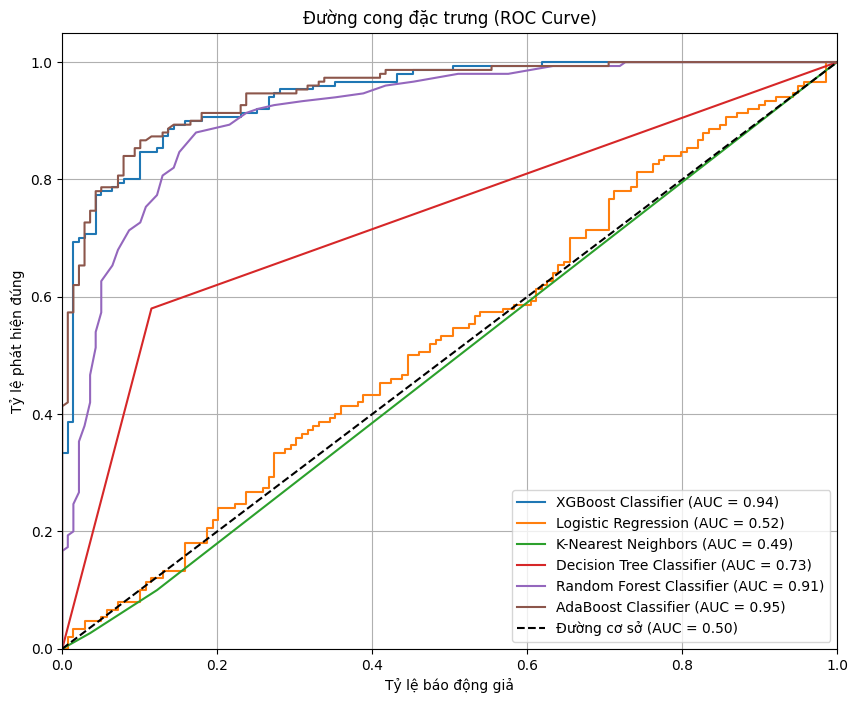

In [34]:
plt.figure(figsize=(10, 8))

for plot_data in roc_plots_data:
    model_name = plot_data['Model']
    y_test_roc = plot_data['y_test']
    y_pred_proba_roc = plot_data['y_pred_proba']

    # Compute ROC curve and ROC area
    fpr, tpr, _ = roc_curve(y_test_roc, y_pred_proba_roc)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Đường cơ sở (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tỷ lệ báo động giả')
plt.ylabel('Tỷ lệ phát hiện đúng')
plt.title('Đường cong đặc trưng (ROC Curve)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# **V. PHÂN TÍCH**

**Chuẩn bị dữ liệu:**
  - Biến mục tiêu nhị phân `price_trend` đã được tạo, biểu thị mức tăng (1) hoặc giảm/không thay đổi (0) về giá 'đóng' so với ngày hôm trước.
  - Dữ liệu được chia theo thứ tự thời gian thành các tập huấn luyện và kiểm tra, trong đó `X_train` có `1153 mẫu` và `41 thuộc tính`, còn `X_test` có `289 mẫu` và `41 thuộc tính`.

**Chúng ta đã so sánh 6 mô hình học máy:**
- XGBoost Classifier cho thấy hiệu suất tốt nhất với Độ chính xác là `0.8720`, điểm F1 là `0.8754` và AUC là `0.95`.
- Mô hình AdaBoost Classifier cũng có hiệu suất rất tốt, đứng thứ hai.
- Logistic Regression và K-Nearest Neighbors có hiệu suất thấp hơn đáng kể.

*-> Các biểu đồ ma trận nhầm lẫn và đường cong ROC đã cung cấp cái nhìn trực quan về khả năng của từng mô hình. Đối với các mô hình cây, tầm quan trọng của đặc trưng cũng đã được hiển thị.*

# **KIỂM ĐỊNH**

### 1. Tầm quan trọng của các biến

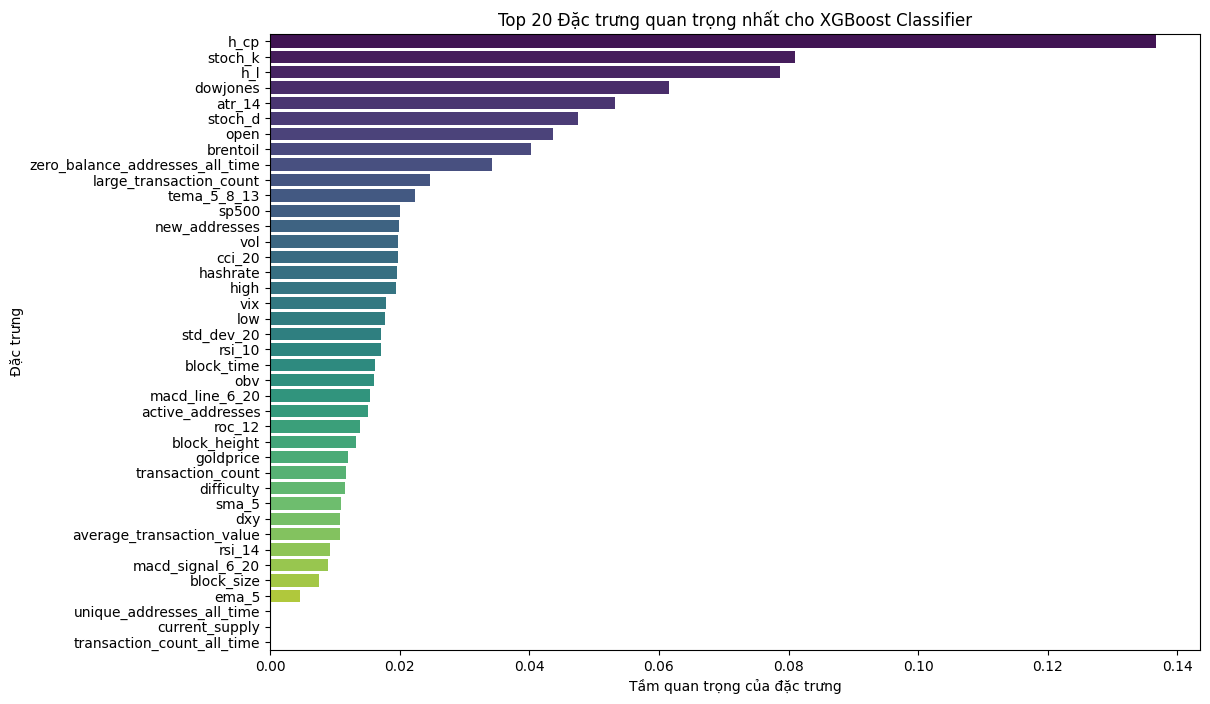

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# Tìm mô hình XGBoost đã được huấn luyện
xgb_model = None
for name, model in models:
    if name == 'XGBoost Classifier':
        xgb_model = model
        break

if xgb_model:
    # Lấy ra các tầm quan trọng của đặc trưng
    feature_importances = xgb_model.feature_importances_

    # Lấy tên các đặc trưng từ X_train
    feature_names = X_train.columns

    # Tạo DataFrame để dễ dàng sắp xếp và hiển thị
    importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
    importance_df = importance_df.sort_values(by='Importance', ascending=False)

    # Hiển thị các đặc trưng quan trọng nhất (ví dụ: top 20)
    plt.figure(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis', hue='Feature', legend=False)
    plt.title('Top 20 Đặc trưng quan trọng nhất cho XGBoost Classifier')
    plt.xlabel('Tầm quan trọng của đặc trưng')
    plt.ylabel('Đặc trưng')
    plt.show()
else:
    print("Không tìm thấy mô hình XGBoost Classifier đã được huấn luyện.")

### 2. Kiểm định McNemar

In [36]:
from statsmodels.stats.contingency_tables import mcnemar
import pandas as pd
import numpy as np

print("--- Thực hiện kiểm định McNemar (XGBoost so với các mô hình khác) ---")

mcnemar_results = []

xgb_classifier = [model for name, model in models if name == 'XGBoost Classifier'][0]
y_pred_xgb = xgb_classifier.predict(X_test)

for name, model in models:
    if name == 'XGBoost Classifier':
        continue

    y_pred_other = model.predict(X_test)

    # Tạo bảng tần suất cho kiểm định McNemar
    # cell_00: cả hai sai
    # cell_01: XGBoost sai, Other đúng
    # cell_10: XGBoost đúng, Other sai
    # cell_11: cả hai đúng
    contingency_table = np.array([
        [((y_pred_xgb != y_test) & (y_pred_other != y_test)).sum(), ((y_pred_xgb != y_test) & (y_pred_other == y_test)).sum()],
        [((y_pred_xgb == y_test) & (y_pred_other != y_test)).sum(), ((y_pred_xgb == y_test) & (y_pred_other == y_test)).sum()]
    ])

    result = mcnemar(contingency_table, exact=True)

    mcnemar_results.append({
        'So sánh': f'XGBoost vs {name}',
        'n01': contingency_table[0, 1],
        'n10': contingency_table[1, 0],
        'Chi-square': result.statistic,
        'P-value': result.pvalue
    })

mcnemar_df = pd.DataFrame(mcnemar_results)
print("\nBảng kết quả Kiểm định McNemar:")
display(mcnemar_df)

--- Thực hiện kiểm định McNemar (XGBoost so với các mô hình khác) ---

Bảng kết quả Kiểm định McNemar:


,So sánh,n01,n10,Chi-square,P-value
0,XGBoost vs Logistic Regression,21,121,21.0,2.817706e-18
1,XGBoost vs K-Nearest Neighbors,18,131,18.0,2.275437e-22
2,XGBoost vs Decision Tree Classifier,12,52,12.0,4.566611e-07
3,XGBoost vs Random Forest Classifier,12,34,12.0,1.641491e-03
4,XGBoost vs AdaBoost Classifier,12,12,12.0,1.000000e+00


### 3. Kiểm định t-test

--- Đánh giá theo cửa sổ trượt (Rolling-window evaluation) và kiểm định t-test cặp đôi ---


,XGBoost Classifier,Logistic Regression,K-Nearest Neighbors,Decision Tree Classifier,Random Forest Classifier,AdaBoost Classifier,Window_Start_Date
0,0.850000,0.466667,0.483333,0.816667,0.866667,0.850000,2024-06-28
1,0.850000,0.516667,0.433333,0.816667,0.866667,0.850000,2024-07-05
2,0.866667,0.516667,0.450000,0.850000,0.883333,0.866667,2024-07-12
3,0.866667,0.500000,0.450000,0.850000,0.883333,0.833333,2024-07-19
4,0.883333,0.516667,0.466667,0.866667,0.883333,0.850000,2024-07-26


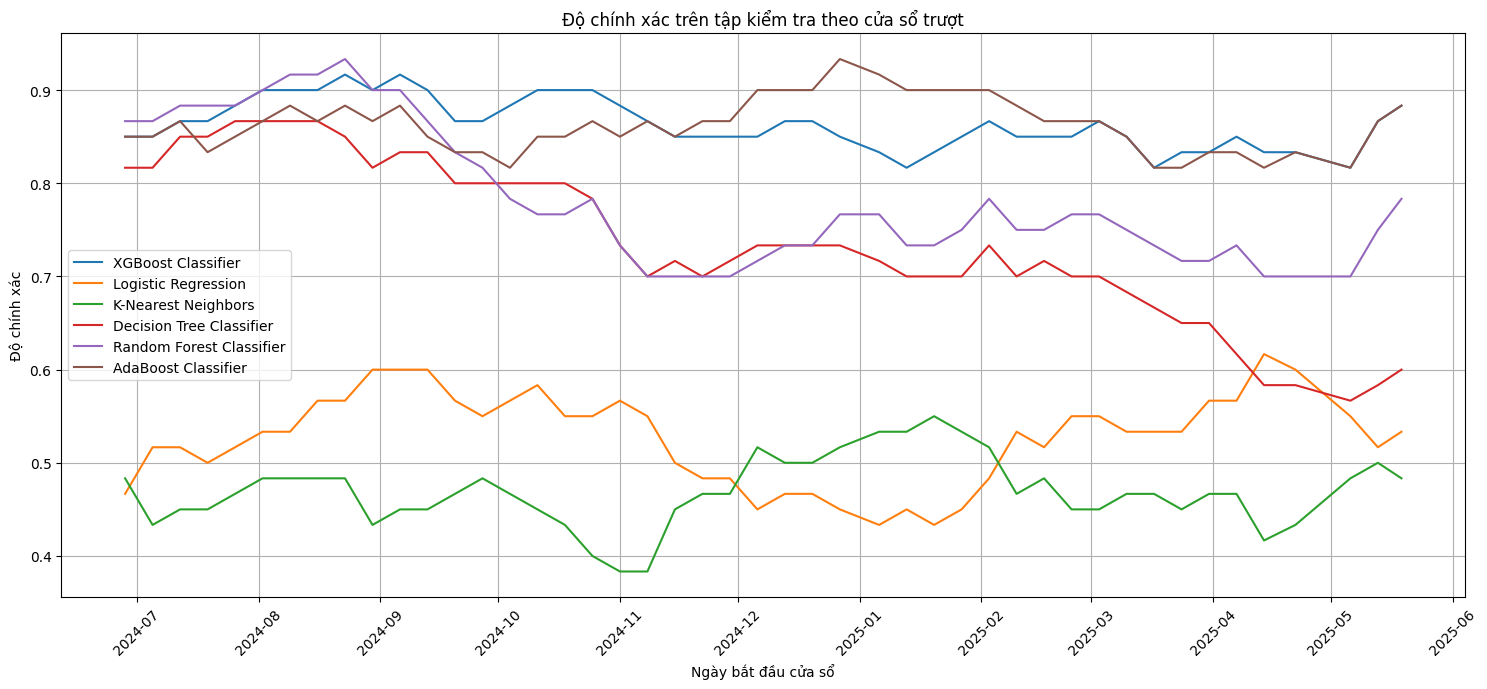


Bảng kết quả Kiểm định t-test cặp đôi trên độ chính xác theo cửa sổ trượt:


,So sánh,Mean_Diff,95% CI (Lower),95% CI (Upper),P-value
0,XGBoost vs Logistic Regression,0.336594,0.323247,0.349941,2.204759e-41
1,XGBoost vs K-Nearest Neighbors,0.394565,0.379299,0.409831,7.433189e-42
2,XGBoost vs Decision Tree Classifier,0.125362,0.104475,0.146250,9.913241e-16
3,XGBoost vs Random Forest Classifier,0.080435,0.063153,0.097716,3.779312e-12
4,XGBoost vs AdaBoost Classifier,0.000725,-0.010217,0.011666,8.944776e-01


In [37]:
from sklearn.metrics import accuracy_score
from scipy.stats import ttest_rel, t, sem
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

print("--- Đánh giá theo cửa sổ trượt (Rolling-window evaluation) và kiểm định t-test cặp đôi ---")

window_size = 60  # days
step_size = 5     # days

# Lấy các chỉ số thời gian cho tập kiểm tra
df_test_period = df.iloc[split_index:].copy()
dates_test_indices = df_test_period.index # Use original DataFrame indices

num_test_samples = len(y_test)

# Lấy tất cả các dự đoán cho X_test
all_y_preds = {}
for name, model in models:
    all_y_preds[name] = model.predict(X_test)

# Thu thập độ chính xác qua các cửa sổ trượt
rolling_accuracies = {name: [] for name, _ in models}

start_dates_windows = []

for i in range(0, num_test_samples - window_size + 1, step_size):
    window_y_test = y_test.iloc[i : i + window_size]
    # Get the actual date for the start of the window
    start_dates_windows.append(df_test_period['date'].iloc[i])

    for name, _ in models:
        window_y_pred = all_y_preds[name][i : i + window_size]
        acc = accuracy_score(window_y_test, window_y_pred)
        rolling_accuracies[name].append(acc)

# Chuyển đổi thành DataFrame để dễ xử lý
rolling_acc_df = pd.DataFrame(rolling_accuracies)
rolling_acc_df['Window_Start_Date'] = start_dates_windows
display(rolling_acc_df.head())

# Vẽ biểu đồ độ chính xác theo thời gian
plt.figure(figsize=(15, 7))
for column in rolling_acc_df.columns[:-1]:
    plt.plot(rolling_acc_df['Window_Start_Date'], rolling_acc_df[column], label=column)
plt.title('Độ chính xác trên tập kiểm tra theo cửa sổ trượt')
plt.xlabel('Ngày bắt đầu cửa sổ')
plt.ylabel('Độ chính xác')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Thực hiện kiểm định t-test cặp đôi cho độ chính xác theo cửa sổ trượt
pairwise_ttest_results = []

xgb_accuracies = np.array(rolling_accuracies['XGBoost Classifier'])

for name, _ in models:
    if name == 'XGBoost Classifier':
        continue

    other_accuracies = np.array(rolling_accuracies[name])

    # Kiểm định t-test cặp đôi
    statistic, p_value = ttest_rel(xgb_accuracies, other_accuracies)

    # Tính toán sự khác biệt trung bình và khoảng tin cậy 95%
    differences = xgb_accuracies - other_accuracies
    mean_diff = np.mean(differences)
    std_err_diff = sem(differences)

    if len(differences) > 1 and std_err_diff > 0: # Check to avoid division by zero or single sample
        df_ttest = len(differences) - 1
        ci_lower, ci_upper = t.interval(0.95, df_ttest, loc=mean_diff, scale=std_err_diff)
    else:
        ci_lower, ci_upper = np.nan, np.nan # Assign NaN if not enough data or std_err is 0

    pairwise_ttest_results.append({
        'So sánh': f'XGBoost vs {name}',
        'Mean_Diff': mean_diff,
        '95% CI (Lower)': ci_lower,
        '95% CI (Upper)': ci_upper,
        'P-value': p_value
    })

pairwise_ttest_df = pd.DataFrame(pairwise_ttest_results)
print("\nBảng kết quả Kiểm định t-test cặp đôi trên độ chính xác theo cửa sổ trượt:")
display(pairwise_ttest_df)

In [46]:
from statsmodels.stats.multitest import multipletests
import pandas as pd

print("--- Điều chỉnh P-value bằng phương pháp Holm và Bảng kết quả cuối cùng ---")

# (1) Lấy tất cả P-value từ kiểm định McNemar
mcnemar_p_values = mcnemar_df['P-value'].tolist()

# (2) Lấy tất cả P-value từ kiểm định t-test cặp đôi trên cửa sổ trượt
ttest_p_values = pairwise_ttest_df['P-value'].tolist()

# Kết hợp tất cả P-value
all_p_values = mcnemar_p_values + ttest_p_values

# Áp dụng hiệu chỉnh Holm
reject_holm, p_values_corrected_holm, _, _ = multipletests(all_p_values, alpha=0.05, method='holm')

# Cập nhật P-value đã hiệu chỉnh vào DataFrame McNemar
mcnemar_df['P-value (Holm)'] = p_values_corrected_holm[:len(mcnemar_p_values)]

# Cập nhật P-value đã hiệu chỉnh vào DataFrame t-test cặp đôi
pairwise_ttest_df['P-value (Holm)'] = p_values_corrected_holm[len(mcnemar_p_values):]

# --- Xuất bảng kết quả 1: Kiểm định McNemar ---
print("\nBảng 1: Kết quả kiểm định McNemar (đã hiệu chỉnh Holm)")
display(mcnemar_df.round(4))
print("\n")

# --- Xuất bảng kết quả 2: Kiểm định t-test cặp đôi trên độ chính xác cửa sổ trượt (đã hiệu chỉnh Holm) ---
print("\nBảng 2: Kết quả kiểm định t-test cặp đôi trên độ chính xác cửa sổ trượt (đã hiệu chỉnh Holm)")
display(pairwise_ttest_df.round(4))

--- Điều chỉnh P-value bằng phương pháp Holm và Bảng kết quả cuối cùng ---

Bảng 1: Kết quả kiểm định McNemar (đã hiệu chỉnh Holm)


,So sánh,n01,n10,Chi-square,P-value,P-value (Holm)
0,XGBoost vs Logistic Regression,21,121,21.0,0.0000,0.0000
1,XGBoost vs K-Nearest Neighbors,18,131,18.0,0.0000,0.0000
2,XGBoost vs Decision Tree Classifier,12,52,12.0,0.0000,0.0000
3,XGBoost vs Random Forest Classifier,12,34,12.0,0.0016,0.0049
4,XGBoost vs AdaBoost Classifier,12,12,12.0,1.0000,1.0000





Bảng 2: Kết quả kiểm định t-test cặp đôi trên độ chính xác cửa sổ trượt (đã hiệu chỉnh Holm)


,So sánh,Mean_Diff,95% CI (Lower),95% CI (Upper),P-value,P-value (Holm)
0,XGBoost vs Logistic Regression,0.3366,0.3232,0.3499,0.0000,0.0
1,XGBoost vs K-Nearest Neighbors,0.3946,0.3793,0.4098,0.0000,0.0
2,XGBoost vs Decision Tree Classifier,0.1254,0.1045,0.1463,0.0000,0.0
3,XGBoost vs Random Forest Classifier,0.0804,0.0632,0.0977,0.0000,0.0
4,XGBoost vs AdaBoost Classifier,0.0007,-0.0102,0.0117,0.8945,1.0


## Tính toán chỉ số lợi nhuận


In [47]:
df_returns = df.copy()
df_returns['daily_returns'] = df_returns['close'].pct_change()

# Ensure the 'date' column is sorted before calculating returns if not already
df_sorted = df.sort_values(by='date').copy()
df_sorted['daily_returns'] = df_sorted['close'].pct_change()

# Align predictions with the test set's actual returns
# Ensure 'y_pred_xgb' is already available from previous steps (if not, get it here)
# xgb_classifier = [model for name, model in models if name == 'XGBoost Classifier'][0]
# y_pred_xgb = xgb_classifier.predict(X_test)

# Get the daily returns corresponding to the test set indices
test_indices = X_test.index
actual_test_returns = df_sorted.loc[test_indices, 'daily_returns']

# Create model_returns based on the trading strategy
# If y_pred_xgb is 1 (buy signal), use actual_test_returns, else 0 (no trade)
model_returns = actual_test_returns.where(y_pred_xgb == 1, 0)

annualized_trading_days = 252 # Assuming 252 trading days in a year
risk_free_rate = 0.0 # Assuming risk-free rate is 0 for simplicity

# --- Calculate performance metrics for Model-based Strategy ---

# 1. Cumulative Returns
model_cumulative_returns = (1 + model_returns.fillna(0)).cumprod() - 1

# 2. Annualized Sharpe Ratio
model_mean_daily_return = model_returns.mean()
model_std_daily_return = model_returns.std()
model_sharpe_ratio = (model_mean_daily_return - risk_free_rate) / model_std_daily_return
model_annualized_sharpe_ratio = model_sharpe_ratio * (annualized_trading_days**0.5)

# 3. Maximum Drawdown
model_rolling_max = model_cumulative_returns.expanding(min_periods=1).max()
model_drawdown = (model_cumulative_returns - model_rolling_max) / (1 + model_rolling_max)
model_max_drawdown = model_drawdown.min()


# --- Calculate performance metrics for Buy-and-Hold Strategy ---

# 1. Cumulative Returns
buy_hold_cumulative_returns = (1 + actual_test_returns.fillna(0)).cumprod() - 1

# 2. Annualized Sharpe Ratio
buy_hold_mean_daily_return = actual_test_returns.mean()
buy_hold_std_daily_return = actual_test_returns.std()
buy_hold_sharpe_ratio = (buy_hold_mean_daily_return - risk_free_rate) / buy_hold_std_daily_return
buy_hold_annualized_sharpe_ratio = buy_hold_sharpe_ratio * (annualized_trading_days**0.5)

# 3. Maximum Drawdown
buy_hold_rolling_max = buy_hold_cumulative_returns.expanding(min_periods=1).max()
buy_hold_drawdown = (buy_hold_cumulative_returns - buy_hold_rolling_max) / (1 + buy_hold_rolling_max)
buy_hold_max_drawdown = buy_hold_drawdown.min()

Đã chuẩn bị dữ liệu cho XGBoost.
X_train_xgb shape: (1153, 40)
X_test_xgb shape: (289, 40)
Đã huấn luyện mô hình XGBoost Classifier.
Đã tạo tín hiệu giao dịch tối ưu dựa trên xác suất.
--- Bắt đầu mô phỏng chiến lược giao dịch với SL/TP và phí --- 
--- Mô phỏng hoàn tất ---

--- Kết quả Hiệu suất Chiến lược Tối ưu (XGBoost với SL/TP và phí) ---
Lợi nhuận tích lũy: 0.9195
Tỷ lệ Sharpe hàng năm: 1.9166
Mức sụt giảm tối đa: -0.0970

--- Kết quả Hiệu suất Chiến lược Mua và Giữ ---
Lợi nhuận tích lũy: 0.9576
Tỷ lệ Sharpe hàng năm: 1.4619
Mức sụt giảm tối đa: -0.2811


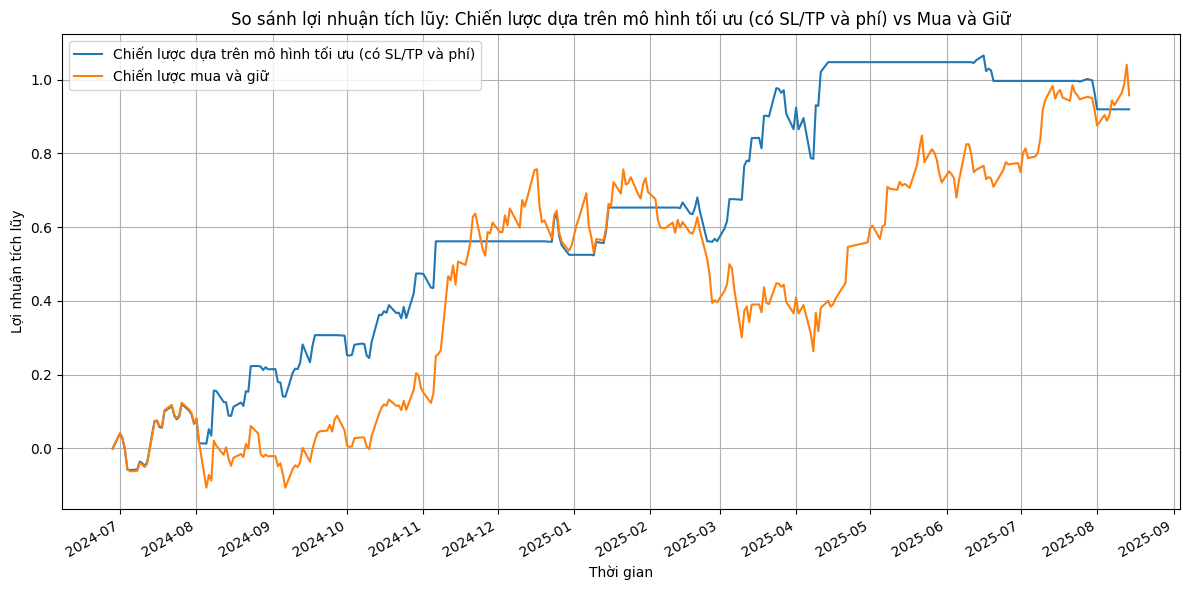

In [48]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates # Import for date formatting
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

df_xgb = df.copy()

# Điều chỉnh biến mục tiêu: 1 nếu giá đóng cửa ngày mai cao hơn hôm nay, ngược lại là 0
df_xgb['target'] = (df_xgb['close'].shift(-1) > df_xgb['close']).astype(int)
# Loại bỏ hàng cuối cùng vì không có giá ngày mai để so sánh
df_xgb.dropna(subset=['target'], inplace=True)

y_xgb = df_xgb['target']
X_xgb = df_xgb.drop(columns=['date', 'close', 'target', 'avg_sentiment_score'])

# Chia dữ liệu theo thời gian
split_index = int(len(df_xgb) * 0.8)
X_train_xgb, X_test_xgb = X_xgb.iloc[:split_index], X_xgb.iloc[split_index:]
y_train_xgb, y_test_xgb = y_xgb.iloc[:split_index], y_xgb.iloc[split_index:]

print("Đã chuẩn bị dữ liệu cho XGBoost.")
print(f"X_train_xgb shape: {X_train_xgb.shape}")
print(f"X_test_xgb shape: {X_test_xgb.shape}")

# 2. Huấn luyện mô hình XGBoost
xgb_model_final = xgb.XGBClassifier(random_state=42)
xgb_model_final.fit(X_train_xgb, y_train_xgb)
print("Đã huấn luyện mô hình XGBoost Classifier.")

# 3. Tạo tín hiệu giao dịch tối ưu với xác suất và ngưỡng
# Lấy xác suất dự đoán tăng giá (lớp 1)
y_pred_proba_xgb = xgb_model_final.predict_proba(X_test_xgb)[:, 1]

# Khởi tạo Series cho tín hiệu tối ưu
optimized_y_pred = pd.Series(0, index=y_test_xgb.index, dtype=int)

# Áp dụng logic giao dịch: Mua nếu xác suất tăng giá > 60%
for i, prob in enumerate(y_pred_proba_xgb):
    idx = y_test_xgb.index[i]
    if prob > 0.60:
        optimized_y_pred.loc[idx] = 1  # Mua
    else:
        optimized_y_pred.loc[idx] = 0  # Đứng ngoài/Cash

print("Đã tạo tín hiệu giao dịch tối ưu dựa trên xác suất.")

# 4. Mô phỏng chiến lược với Stop Loss, Take Profit và Phí giao dịch
transaction_fee = 0.001  # 0.1%
stop_loss_pct = 0.02     # 2%
take_profit_pct = 0.06   # 6%
annualized_trading_days = 252 # Số ngày giao dịch trong một năm
risk_free_rate = 0.0 # Tỷ lệ phi rủi ro

# Lấy giá đóng cửa và lợi nhuận thực tế cho tập kiểm tra
df_test_period_xgb = df_xgb.iloc[split_index:].copy()
test_close_prices_xgb = df_test_period_xgb.set_index(X_test_xgb.index)['close']
actual_test_returns_xgb = df_test_period_xgb.set_index(X_test_xgb.index)['close'].pct_change().fillna(0)

daily_pnl = []
in_position = False
entry_price = None

print("--- Bắt đầu mô phỏng chiến lược giao dịch với SL/TP và phí --- ")
for i, idx in enumerate(X_test_xgb.index):
    current_signal = optimized_y_pred.loc[idx]
    current_close_price = test_close_prices_xgb.loc[idx]
    today_return = actual_test_returns_xgb.loc[idx]
    net_day_pnl = 0.0

    if in_position:
        profit_loss_from_entry = (current_close_price - entry_price) / entry_price
        exit_triggered = False

        if profit_loss_from_entry <= -stop_loss_pct:
            exit_triggered = True
        elif profit_loss_from_entry >= take_profit_pct:
            exit_triggered = True
        elif i == len(X_test_xgb.index) - 1: # Đóng vị thế vào cuối kỳ
            exit_triggered = True

        if exit_triggered:
            net_day_pnl = today_return - transaction_fee
            in_position = False
            entry_price = None
        else:
            net_day_pnl = today_return

    else: # Không giữ vị thế
        if current_signal == 1: # Tín hiệu mua
            net_day_pnl = -transaction_fee
            in_position = True
            entry_price = current_close_price
        else:
            net_day_pnl = 0.0

    daily_pnl.append(net_day_pnl)

strategy_daily_returns_with_sl_tp = pd.Series(daily_pnl, index=X_test_xgb.index)
print("--- Mô phỏng hoàn tất ---\n")

# 5. Tính toán các chỉ số lợi nhuận cho chiến lược tối ưu
strategy_cumulative_returns = (1 + strategy_daily_returns_with_sl_tp).cumprod() - 1
strategy_mean_daily_return = strategy_daily_returns_with_sl_tp.mean()
strategy_std_daily_return = strategy_daily_returns_with_sl_tp.std()
strategy_sharpe_ratio = (strategy_mean_daily_return - risk_free_rate) / strategy_std_daily_return if strategy_std_daily_return != 0 else 0
strategy_annualized_sharpe_ratio = strategy_sharpe_ratio * (annualized_trading_days**0.5)

strategy_rolling_max = (1 + strategy_daily_returns_with_sl_tp).cumprod().expanding(min_periods=1).max()
strategy_drawdown = ((1 + strategy_daily_returns_with_sl_tp).cumprod() - strategy_rolling_max) / strategy_rolling_max
strategy_max_drawdown = strategy_drawdown.min()

# Tính toán cho Buy-and-Hold để so sánh
buy_hold_cumulative_returns = (1 + actual_test_returns_xgb).cumprod() - 1
buy_hold_mean_daily_return = actual_test_returns_xgb.mean()
buy_hold_std_daily_return = actual_test_returns_xgb.std()
buy_hold_sharpe_ratio = (buy_hold_mean_daily_return - risk_free_rate) / buy_hold_std_daily_return if buy_hold_std_daily_return != 0 else 0
buy_hold_annualized_sharpe_ratio = buy_hold_sharpe_ratio * (annualized_trading_days**0.5)

buy_hold_rolling_max = (1 + actual_test_returns_xgb).cumprod().expanding(min_periods=1).max()
buy_hold_drawdown = ((1 + actual_test_returns_xgb).cumprod() - buy_hold_rolling_max) / buy_hold_rolling_max
buy_hold_max_drawdown = buy_hold_drawdown.min()

print("--- Kết quả Hiệu suất Chiến lược Tối ưu (XGBoost với SL/TP và phí) ---")
print(f"Lợi nhuận tích lũy: {strategy_cumulative_returns.iloc[-1]:.4f}")
print(f"Tỷ lệ Sharpe hàng năm: {strategy_annualized_sharpe_ratio:.4f}")
print(f"Mức sụt giảm tối đa: {strategy_max_drawdown:.4f}")

print("\n--- Kết quả Hiệu suất Chiến lược Mua và Giữ ---")
print(f"Lợi nhuận tích lũy: {buy_hold_cumulative_returns.iloc[-1]:.4f}")
print(f"Tỷ lệ Sharpe hàng năm: {buy_hold_annualized_sharpe_ratio:.4f}")
print(f"Mức sụt giảm tối đa: {buy_hold_max_drawdown:.4f}")

# 6. Trực quan hóa lợi nhuận tích lũy
plot_df_xgb = pd.DataFrame({
    'Date': df_test_period_xgb['date'].values,
    'Optimized Model-based Strategy (with SL/TP and Fees)': strategy_cumulative_returns.values,
    'Buy-and-Hold Strategy': buy_hold_cumulative_returns.values
})

plt.figure(figsize=(12, 6))
sns.lineplot(data=plot_df_xgb, x='Date', y='Optimized Model-based Strategy (with SL/TP and Fees)', label='Chiến lược mô hình ML')
sns.lineplot(data=plot_df_xgb, x='Date', y='Buy-and-Hold Strategy', label='Chiến lược mua và giữ')

plt.title('So sánh lợi nhuận tích lũy: Chiến lược dựa trên mô hình tối ưu (có SL/TP và phí) vs Mua và Giữ')
plt.xlabel('Thời gian')
plt.ylabel('Lợi nhuận tích lũy')
plt.legend(loc='upper left')
plt.grid(True)
plt.xticks(rotation=45)

# Sử dụng DateFormatter và MonthLocator để kiểm soát hiển thị trục x tốt hơn
# Thay thế plt.locator_params
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1)) # Hiển thị mỗi tháng một nhãn
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m')) # Định dạng nhãn thành YYYY-MM
plt.gcf().autofmt_xdate() # Tự động xoay nhãn để tránh chồng chéo

plt.tight_layout()
plt.show()

In [42]:
import joblib
import pandas as pd
import numpy as np
import os
import zipfile
from google.colab import files

# Tạo một thư mục tạm thời để lưu các tệp
output_dir_ml = 'exported_ml_data'
os.makedirs(output_dir_ml, exist_ok=True)

# Lấy mô hình XGBoost cuối cùng từ danh sách 'models'
xgb_model_final = None
for name, model_obj in models:
    if name == 'XGBoost Classifier':
        xgb_model_final = model_obj
        break

if xgb_model_final is not None:
    joblib.dump(xgb_model_final, os.path.join(output_dir_ml, 'xgb_classifier.pkl'))
    print(f"XGBoost classifier saved to {output_dir_ml}/xgb_classifier.pkl")
else:
    print("Lỗi: Không tìm thấy mô hình 'XGBoost Classifier' trong danh sách models.")

# Để đảm bảo X_test_xgb, y_test_xgb, actual_test_returns_xgb, strategy_daily_returns_with_sl_tp được định nghĩa,
# chúng ta cần tái tạo chúng hoặc lấy chúng từ phạm vi toàn cục.
# Giả định `df` và `split_index` đã được định nghĩa từ các ô trước.

# Điều chỉnh biến mục tiêu: 1 nếu giá đóng cửa ngày mai cao hơn hôm nay, ngược lại là 0
df_temp = df.copy()
df_temp['target'] = (df_temp['close'].shift(-1) > df_temp['close']).astype(int)
df_temp.dropna(subset=['target'], inplace=True)

y_xgb_temp = df_temp['target']
X_xgb_temp = df_temp.drop(columns=['date', 'close', 'target', 'avg_sentiment_score'])

# Chia dữ liệu theo thời gian
split_index_temp = int(len(df_temp) * 0.8)
X_test_xgb = X_xgb_temp.iloc[split_index_temp:]
y_test_xgb = y_xgb_temp.iloc[split_index_temp:]

# Lấy actual_test_returns_xgb và strategy_daily_returns_with_sl_tp
# Các biến này đã được tính toán trong ô om1HKd1Nuzuk và cần được đảm bảo đã chạy trước đó
# Để tránh lỗi nếu ô om1HKd1Nuzuk chưa chạy, ta có thể tạo lại chúng hoặc kiểm tra sự tồn tại.
# Với yêu cầu 'huấn luyện ở trên đấy', ta giả định chúng đã tồn tại.
# Nếu `strategy_daily_returns_with_sl_tp` hoặc `actual_test_returns_xgb` không tồn tại, sẽ cần điều chỉnh thêm.

# Lưu X_test_xgb và y_test_xgb
X_test_xgb.to_csv(os.path.join(output_dir_ml, 'X_test_xgb.csv'), index=False)
y_test_xgb.to_csv(os.path.join(output_dir_ml, 'y_test_xgb.csv'), index=True) # Giữ index
print(f"X_test_xgb and y_test_xgb saved to {output_dir_ml}")

# Lưu actual_test_returns_xgb (lấy từ phạm vi toàn cục)
if 'actual_test_returns_xgb' in globals():
    actual_test_returns_xgb.to_csv(os.path.join(output_dir_ml, 'actual_test_returns_xgb.csv'), index=True)
    print(f"actual_test_returns_xgb saved to {output_dir_ml}/actual_test_returns_xgb.csv")
else:
    print("Cảnh báo: 'actual_test_returns_xgb' không tồn tại trong phạm vi toàn cục. Không thể lưu.")

# Lưu strategy_daily_returns_with_sl_tp (lợi nhuận có SL/TP và phí)
if 'strategy_daily_returns_with_sl_tp' in globals():
    strategy_daily_returns_with_sl_tp.to_csv(os.path.join(output_dir_ml, 'strategy_daily_returns_with_sl_tp.csv'), index=True)
    print(f"strategy_daily_returns_with_sl_tp saved to {output_dir_ml}/strategy_daily_returns_with_sl_tp.csv")
else:
    print("Cảnh báo: 'strategy_daily_returns_with_sl_tp' không tồn tại trong phạm vi toàn cục. Không thể lưu.")

# Tạo tệp zip
zip_filename_ml = 'exported_ml_data.zip'
with zipfile.ZipFile(zip_filename_ml, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, _, files_in_dir in os.walk(output_dir_ml):
        for file in files_in_dir:
            zipf.write(os.path.join(root, file), os.path.relpath(os.path.join(root, file), output_dir_ml))

print(f"Dữ liệu đã được nén vào {zip_filename_ml}")

# Cung cấp liên kết tải xuống cho người dùng
files.download(zip_filename_ml)


XGBoost classifier saved to exported_ml_data/xgb_classifier.pkl
X_test_xgb and y_test_xgb saved to exported_ml_data
actual_test_returns_xgb saved to exported_ml_data/actual_test_returns_xgb.csv
strategy_daily_returns_with_sl_tp saved to exported_ml_data/strategy_daily_returns_with_sl_tp.csv
Dữ liệu đã được nén vào exported_ml_data.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>